# Diagnóstico Visual de Doenças Cardíacas

## Cenário (O Problema)
Você é um(a) Cientista de Dados em uma clínica de cardiologia e recebeu a tarefa de identificar padrões de risco de doença cardíaca utilizando o conjunto de dados heart.csv. O objetivo é auxiliar os médicos no diagnóstico rápido, transformando dados brutos em insights visuais claros e acionáveis. Sua entrega final será um notebook com 8 visualizações distintas que contam uma história sobre os fatores de risco.

## Tarefa: Análise Exploratória e Visualização Avançada
O desafio é ir além dos gráficos básicos e utilizar os recursos avançados de Matplotlib, Seaborn e Plotly para responder a questões complexas sobre a relação entre variáveis clínicas e a presença de doença cardíaca (output).

## Requisitos de Análise (Mínimo de 8 Gráficos Requeridos)
Vocês devem utilizar cada uma das três bibliotecas pelo menos uma vez e escolher análises que não foram abordadas na aula (por exemplo, explore relações entre outras variáveis).

1. Comparação da Distribuição de Idade e Colesterol por Doença;
2. Relação entre Pressão Arterial e Tipo de Dor no Peito;
3. Gere um sns.heatmap para visualizar a matriz de correlação de todas as variáveis numéricas;
4. Utilize um sns.FacetGrid combinado com um sns.kdeplot para visualizar a distribuição da Frequência Cardíaca Máxima (thalachh), separando o gráfico por sex (sexo) e exng (angina induzida por exercício).
5. Crie um plotly.express.scatter_3d com as seguintes variáveis:
  - Eixo X: chol (Colesterol)
  - Eixo Y: thalachh (Frequência Cardíaca Máxima)
  - Eixo Z: oldpeak (Depressão do ST)

Pergunta: Gire o gráfico e identifique se a doença cardíaca é separável em um espaço tridimensional por essas três variáveis.

6. Crie um plotly.express.bar para visualizar a contagem de pacientes por restecg (eletrocardiograma em repouso), e utilize o parâmetro color para diferenciar a variável alvo (output).
7. Crie um plotly.express.sunburst ou plotly.express.treemap para visualizar a hierarquia e a contagem de pacientes que têm ou não doença cardíaca (output) com base em dois fatores categóricos: sex e fbs (açúcar no sangue em jejum).
8. Utilize a biblioteca de sua preferência para criar um Boxen Plot (sns.boxenplot) ou um gráfico de Raincloud (se souber implementar ou usar uma extensão), focando na variável age (idade) agrupada por caa (número de vasos principais).

In [2]:
import os 
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import plotly.express as px
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import accuracy_score, roc_auc_score,roc_curve

In [3]:
current_path = os.getcwd()
current_path

'c:\\Users\\henrique.cordeiro\\OneDrive - Sociedade Campineira de Educação e Instrução\\A-POS\\LINGUAGEM DE PROGRAMAÇÃO PYTHON APLICADA A VISUALIZAÇÃO DE DADOS'

In [4]:
df_heart = pd.read_csv(os.path.join(current_path,"heart.csv"))
df_heart.head()

,age,sex,cp,trtbps,chol,fbs,restecg,thalachh,exng,oldpeak,slp,caa,thall,output
0,63,1,3,145,233,1,0,150,0,2.3,0,0,1,1
1,37,1,2,130,250,0,1,187,0,3.5,0,0,2,1
2,41,0,1,130,204,0,0,172,0,1.4,2,0,2,1
3,56,1,1,120,236,0,1,178,0,0.8,2,0,2,1
4,57,0,0,120,354,0,1,163,1,0.6,2,0,2,1


In [5]:
len(df_heart)

303

In [6]:
df_heart.info()


<class 'pandas.core.frame.DataFrame'>
RangeIndex: 303 entries, 0 to 302
Data columns (total 14 columns):
 #   Column    Non-Null Count  Dtype  
---  ------    --------------  -----  
 0   age       303 non-null    int64  
 1   sex       303 non-null    int64  
 2   cp        303 non-null    int64  
 3   trtbps    303 non-null    int64  
 4   chol      303 non-null    int64  
 5   fbs       303 non-null    int64  
 6   restecg   303 non-null    int64  
 7   thalachh  303 non-null    int64  
 8   exng      303 non-null    int64  
 9   oldpeak   303 non-null    float64
 10  slp       303 non-null    int64  
 11  caa       303 non-null    int64  
 12  thall     303 non-null    int64  
 13  output    303 non-null    int64  
dtypes: float64(1), int64(13)
memory usage: 33.3 KB


In [7]:
df_heart.describe()

,age,sex,cp,trtbps,chol,fbs,restecg,thalachh,exng,oldpeak,slp,caa,thall,output
count,303.000000,303.000000,303.000000,303.000000,303.000000,303.000000,303.000000,303.000000,303.000000,303.000000,303.000000,303.000000,303.000000,303.000000
mean,54.366337,0.683168,0.966997,131.623762,246.264026,0.148515,0.528053,149.646865,0.326733,1.039604,1.399340,0.729373,2.313531,0.544554
std,9.082101,0.466011,1.032052,17.538143,51.830751,0.356198,0.525860,22.905161,0.469794,1.161075,0.616226,1.022606,0.612277,0.498835
min,29.000000,0.000000,0.000000,94.000000,126.000000,0.000000,0.000000,71.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000
25%,47.500000,0.000000,0.000000,120.000000,211.000000,0.000000,0.000000,133.500000,0.000000,0.000000,1.000000,0.000000,2.000000,0.000000
50%,55.000000,1.000000,1.000000,130.000000,240.000000,0.000000,1.000000,153.000000,0.000000,0.800000,1.000000,0.000000,2.000000,1.000000
75%,61.000000,1.000000,2.000000,140.000000,274.500000,0.000000,1.000000,166.000000,1.000000,1.600000,2.000000,1.000000,3.000000,1.000000
max,77.000000,1.000000,3.000000,200.000000,564.000000,1.000000,2.000000,202.000000,1.000000,6.200000,2.000000,4.000000,3.000000,1.000000


In [8]:
df_heart_visible = df_heart.copy()

In [9]:
df_heart_visible["sex"] = df_heart_visible["sex"].astype(float).astype("Int64")
df_heart_visible = df_heart_visible.dropna(subset=['sex', 'fbs', 'output'])
df_heart_visible['sex'] = df_heart_visible['sex'].map({0: 'Feminino', 1: 'Masculino'})
df_heart_visible['fbs'] = df_heart_visible['fbs'].map({0: 'Glicose Normal', 1: 'Glicose Alta'})
df_heart_visible['output'] = df_heart_visible['output'].map({0: 'Sem Doença', 1: 'Com Doença'})

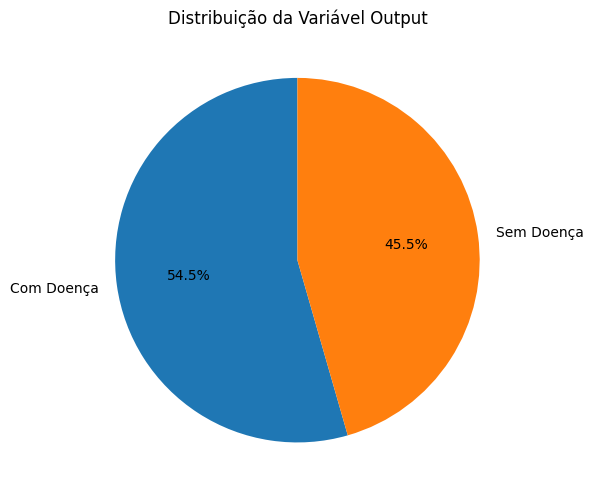

In [10]:
valores = df_heart_visible["output"].value_counts().values
labels = df_heart_visible["output"].value_counts().index

plt.figure(figsize=(6,6))
plt.pie(
    valores,
    labels=labels,
    autopct="%1.1f%%",       
    startangle=90,          
)

plt.title("Distribuição da Variável Output")
plt.tight_layout()
plt.show()

### 1. Comparação da Distribuição de Idade e Colesterol por Doença;

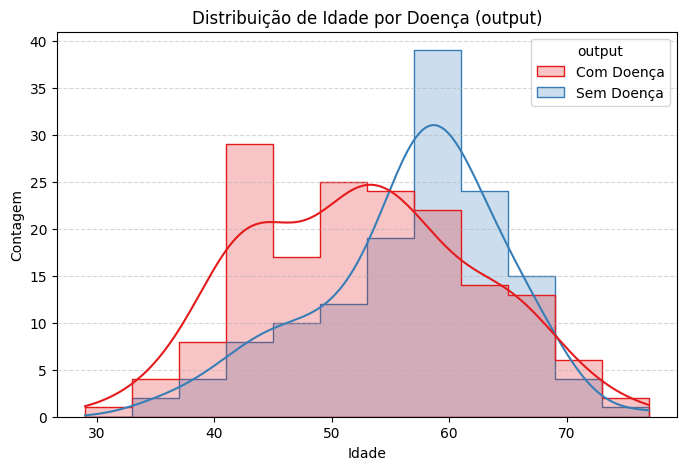

In [11]:
plt.figure(figsize=(8,5))
sns.histplot(data=df_heart_visible, x='age',palette="Set1", hue='output', kde=True, element='step',stat='count' )
plt.grid(axis='y', linestyle='--', alpha=0.5)
plt.title('Distribuição de Idade por Doença (output)')
plt.xlabel('Idade'); plt.ylabel('Contagem')
plt.show()


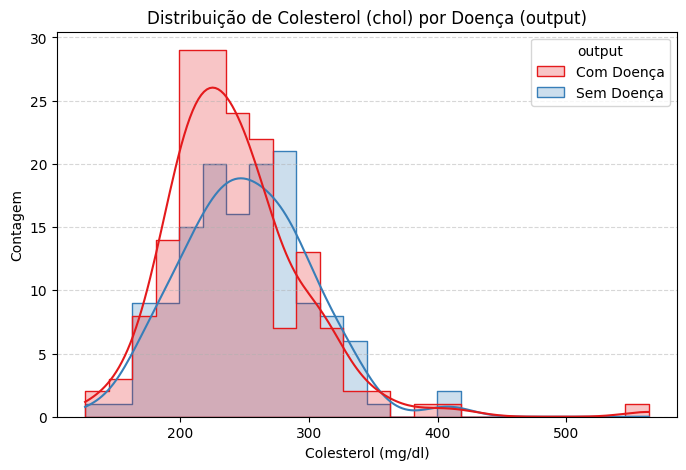

In [12]:
plt.figure(figsize=(8,5))
sns.histplot(data=df_heart_visible, x='chol', hue='output',palette="Set1", kde=True, element='step')
plt.grid(axis='y', linestyle='--', alpha=0.5)
plt.title('Distribuição de Colesterol (chol) por Doença (output)')
plt.xlabel('Colesterol (mg/dl)'); plt.ylabel('Contagem')
plt.show()

# 2. Relação entre Pressão Arterial e Tipo de Dor no Peito

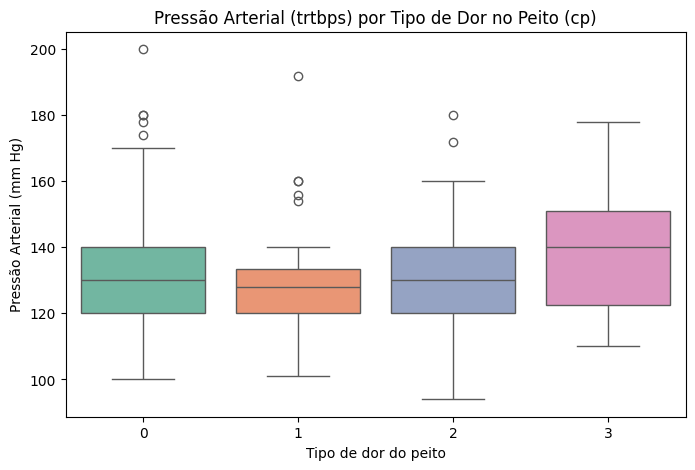

In [13]:
plt.figure(figsize=(8,5))
sns.boxplot(data=df_heart_visible,x='cp',y='trtbps',hue='cp',palette='Set2',legend=False)
plt.title('Pressão Arterial (trtbps) por Tipo de Dor no Peito (cp)')
plt.xlabel('Tipo de dor do peito'); plt.ylabel('Pressão Arterial (mm Hg)')
plt.show()

# 3. Gere um sns.heatmap para visualizar a matriz de correlação de todas as variáveis numéricas

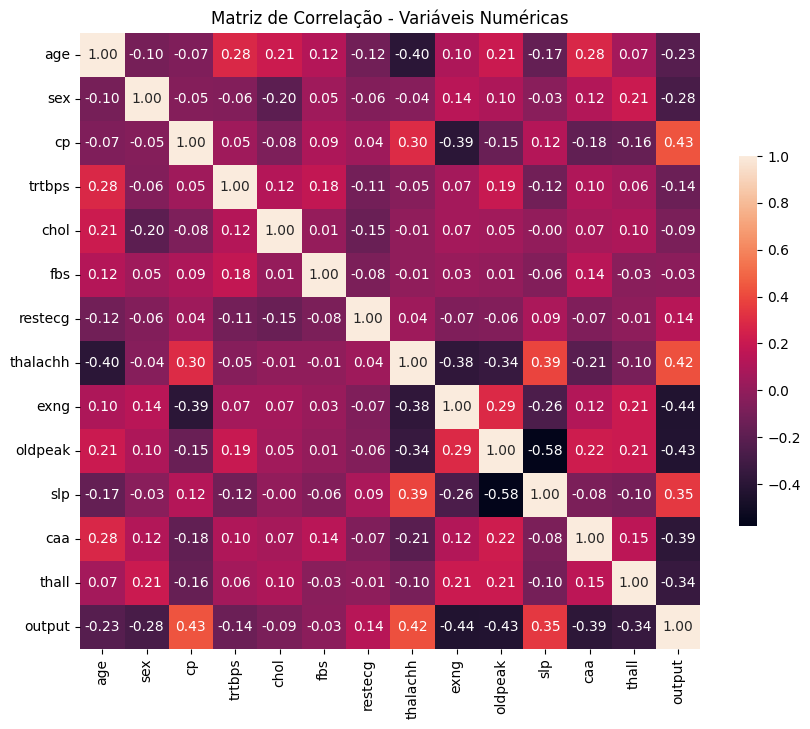

In [14]:
num_df = df_heart.select_dtypes(include=['int64','float64'])
corr = num_df.corr()
plt.figure(figsize=(10,8))
sns.heatmap(corr, annot=True, fmt='.2f',  cbar_kws={'shrink':0.6})
plt.title('Matriz de Correlação - Variáveis Numéricas')
plt.show()

# 4. Utilize um sns.FacetGrid combinado com um sns.kdeplot para visualizar a distribuição da Frequência Cardíaca Máxima (thalachh), separando o gráfico por sex (sexo) e exng (angina induzida por exercício).

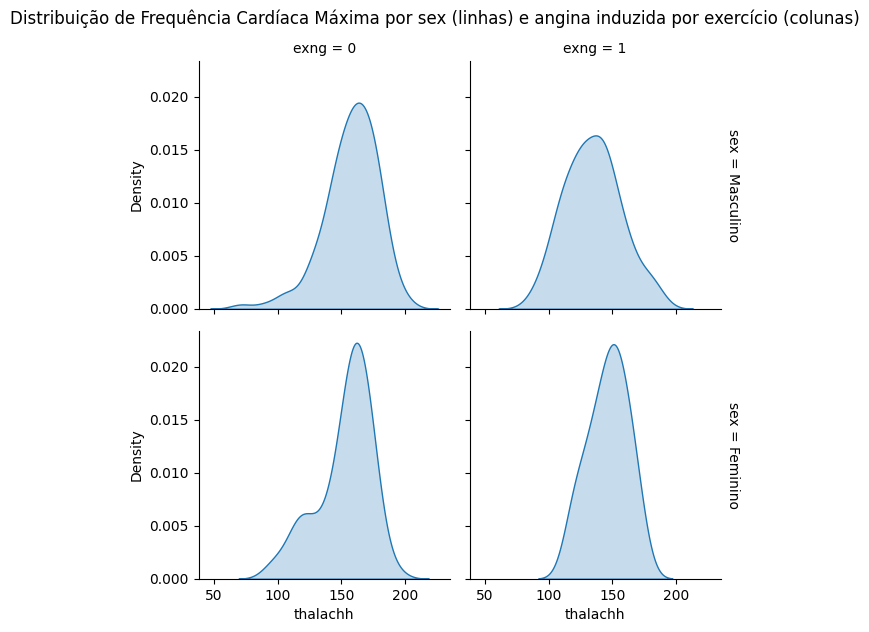

In [15]:
df_heart_visible['sex'] = df_heart_visible['sex'].astype(str)
df_heart_visible['exng'] = df_heart_visible['exng'].astype(str)

FacetGrid = sns.FacetGrid(df_heart_visible, row='sex', col='exng', margin_titles=True, height=3.2)
FacetGrid.map_dataframe(sns.kdeplot, x='thalachh', common_norm=False, fill=True)
FacetGrid.fig.subplots_adjust(top=0.9)
FacetGrid.fig.suptitle('Distribuição de Frequência Cardíaca Máxima por sex (linhas) e angina induzida por exercício (colunas)')
plt.show()

# 5. Crie um plotly.express.scatter_3d com as seguintes variáveis.

In [36]:
df_heart_visible['output'] = df_heart_visible['output'].astype(str)

fig_3d = px.scatter_3d(
    df_heart_visible, 
    x='chol', 
    y='thalachh', 
    z='oldpeak',
    color='output',              
    symbol='output',            
    labels={
        'chol': 'Colesterol',
        'thalachh': 'Frequência Cardíaca Máxima',
        'oldpeak': 'Depressão do ST',
        'output': 'Resultado'
    },
    title='Gráfico 3D: Colesterol x Frequência Cardíaca Máxima x Depressão do ST (color=output)'
)

fig_3d.show()


# 6. Crie um plotly.express.bar para visualizar a contagem de pacientes por restecg (eletrocardiograma em repouso), e utilize o parâmetro color para diferenciar a variável alvo (output)

In [22]:
fig_bar = px.histogram(df_heart_visible, x='restecg', color=df_heart_visible['output'].astype(str), barmode='group',
                       labels={'restecg':'eletrocardiograma em repouso','color':'output'}, title='Contagem por eletrocardiograma em repouso (color=output)')
fig_bar.show()

 # 7. Crie um plotly.express.sunburst ou plotly.express.treemap para visualizar a hierarquia e a contagem de pacientes que têm ou não doença cardíaca (output) com base em dois fatores categóricos: sex e fbs (açúcar no sangue em jejum)

In [ ]:
fig_sun = px.sunburst(
    df_heart_visible,
    path=['sex','fbs','output'],
    title='Sunburst: Sexo X Glicose X Resultado (Contagem)',
)


fig_sun.show()


# 8. Utilize a biblioteca de sua preferência para criar um Boxen Plot (sns.boxenplot) ou um gráfico de Raincloud (se souber implementar ou usar uma extensão), focando na variável age (idade) agrupada por caa (número de vasos principais)

C:\Users\henrique.cordeiro\AppData\Local\Temp\ipykernel_892\1244219940.py:2: FutureWarning:



Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.




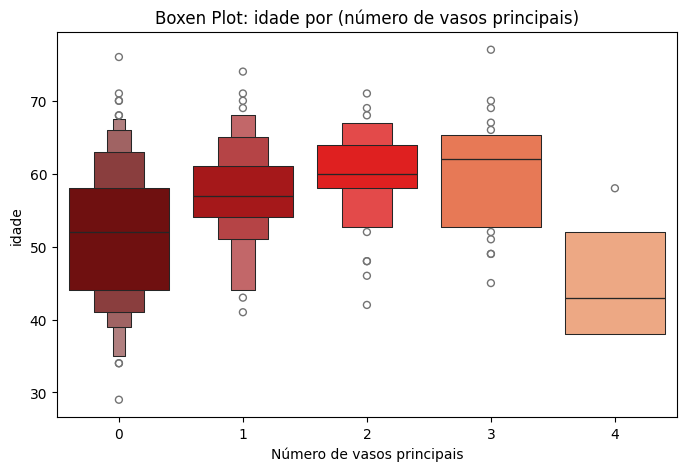

In [21]:
plt.figure(figsize=(8,5))
sns.boxenplot(
    data=df_heart,
    x='caa',
    y='age',
    palette=["#7f0000", "#bd0003", "#ff0000", "#ff6c3e", "#ffa372"]
)
plt.title('Boxen Plot: idade por (número de vasos principais)')
plt.xlabel('Número de vasos principais')
plt.ylabel('idade')
plt.show()


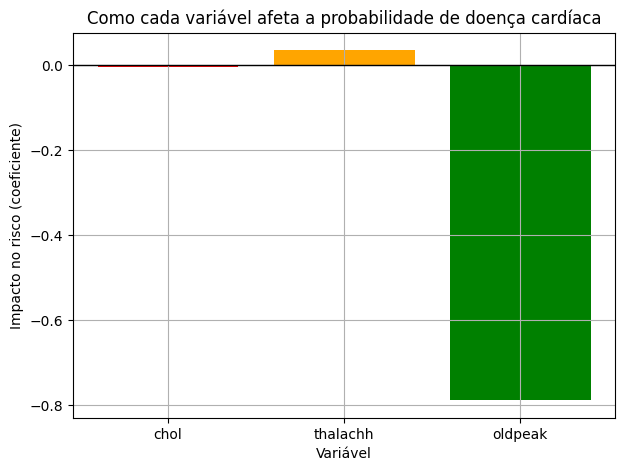

In [32]:

X = df_heart[['chol', 'thalachh', 'oldpeak']].fillna(
    df_heart[['chol', 'thalachh', 'oldpeak']].median()
)
y = df_heart['output']

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.3, random_state=42, stratify=y
)

clf = LogisticRegression(max_iter=2000)
clf.fit(X_train, y_train)

coeffs = clf.coef_[0]
features = X.columns

plt.figure(figsize=(7,5))
plt.bar(features, coeffs, color=['red','orange','green'])
plt.axhline(0, color='black', linewidth=1)
plt.xlabel("Variável")
plt.ylabel("Impacto no risco (coeficiente)")
plt.title("Como cada variável afeta a probabilidade de doença cardíaca")
plt.grid(True)
plt.show()